# Retail Demand Forecasting

[![Dataset](https://img.shields.io/badge/Dataset-Kaggle%20Store%20Sales-20BEFF?logo=kaggle&logoColor=white)](https://www.kaggle.com/competitions/store-sales-time-series-forecasting)
[![Python](https://img.shields.io/badge/Python-3.10-3776AB?logo=python&logoColor=white)](https://www.python.org/)
[![LightGBM](https://img.shields.io/badge/Model-LightGBM-9ACD32?logo=lightgbm&logoColor=white)](https://lightgbm.readthedocs.io/)
[![MLflow](https://img.shields.io/badge/Tracking-MLflow-0194E2?logo=mlflow&logoColor=white)](https://mlflow.org/)
[![SHAP](https://img.shields.io/badge/Explainability-SHAP-FF6B6B)](https://shap.readthedocs.io/)
[![Streamlit](https://img.shields.io/badge/Deployment-Streamlit-FF4B4B?logo=streamlit&logoColor=white)](https://streamlit.io/)

### Goal — Model Training

> **Strategy:** We use a 3-stage approach to maximise accuracy:
> 1. **Naïve baseline** — seasonal average. Sets the performance floor. If our ML model can't beat this, something is wrong.
> 2. **LightGBM** — gradient boosted trees. Industry standard for tabular time-series forecasting. Fast, accurate, handles categoricals natively. used by **Walmart, Amazon, Alibaba**
> 3. **Optuna tuning** — Bayesian hyperparameter search. Finds the optimal model configuration automatically using TimeSeriesSplit cross-validation.



## 1. Setup & Installs

In [1]:
!pip install lightgbm optuna mlflow joblib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.6 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import lightgbm as lgb
import optuna
import mlflow
import mlflow.lightgbm
import joblib
import warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_PATH  = '/content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/'
MODEL_PATH = DATA_PATH + 'models/'

import os
os.makedirs(MODEL_PATH, exist_ok=True)

Mounted at /content/drive


## 2. Load Feature Panel

In [3]:
panel = pd.read_parquet(DATA_PATH + 'panel_features.parquet')

print(f'Shape      : {panel.shape}')
print(f'Date range : {panel["date"].min().date()} → {panel["date"].max().date()}')
print(f'Columns    : {panel.columns.tolist()}')

Shape      : (2950992, 28)
Date range : 2013-01-29 → 2017-08-15
Columns    : ['date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_holiday', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'year', 'is_weekend', 'quarter', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7', 'oil_lag1', 'oil_rolling7', 'days_to_holiday', 'sales_log']


## 3. Define Features & Target

In [4]:
FEATURE_COLS = [
    # Calendar
    'day_of_week', 'day_of_month', 'month', 'week_of_year',
    'year', 'is_weekend', 'quarter',
    # Lags
    'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    # Rolling
    'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7',
    # Oil
    'oil_lag1', 'oil_rolling7',
    # Holiday
    'is_holiday', 'days_to_holiday',
    # Store
    'store_nbr', 'cluster',
    # Categoricals
    'family', 'type', 'city', 'state',
    # Promotion
    'onpromotion'
]

TARGET = 'sales_log'

CAT_COLS = ['family', 'type', 'city', 'state']
for col in CAT_COLS:
    panel[col] = panel[col].astype('category')

print(f'Features : {len(FEATURE_COLS)}')
print(f'Target   : {TARGET}')

Features : 24
Target   : sales_log


## 4. Train / Validation Split

> **Time-based split** — we train on 2013–2016 and validate on the last 3 months of 2017.

In [5]:
CUTOFF = '2017-05-01'

train_df = panel[panel['date'] <  CUTOFF].copy()
val_df   = panel[panel['date'] >= CUTOFF].copy()

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET]
X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET]

print(f'Train size : {len(X_train):,} rows ({train_df["date"].min().date()} → {train_df["date"].max().date()})')
print(f'Val size   : {len(X_val):,} rows   ({val_df["date"].min().date()} → {val_df["date"].max().date()})')
print(f'Val %      : {len(X_val)/len(panel)*100:.1f}%')

Train size : 2,760,318 rows (2013-01-29 → 2017-04-30)
Val size   : 190,674 rows   (2017-05-01 → 2017-08-15)
Val %      : 6.5%


## 5. Naïve Seasonal Baseline

In [7]:
# sales_lag_7 is in RAW sales space, not log space
# so we compare directly without expm1

baseline_preds_raw = val_df['sales_lag_7'].fillna(0).clip(lower=0)
val_actual_raw     = np.expm1(y_val)

# Clip any inf/nan just in case
baseline_preds_raw = baseline_preds_raw.replace([np.inf, -np.inf], 0).fillna(0)
val_actual_raw     = val_actual_raw.replace([np.inf, -np.inf], 0).fillna(0)

baseline_rmse = np.sqrt(mean_squared_error(val_actual_raw, baseline_preds_raw))
baseline_mae  = mean_absolute_error(val_actual_raw, baseline_preds_raw)

mask = val_actual_raw > 0
baseline_mape = np.mean(
    np.abs((val_actual_raw[mask] - baseline_preds_raw[mask]) / val_actual_raw[mask])
) * 100

print('=== Naïve Seasonal Baseline ===')
print(f'RMSE : {baseline_rmse:,.2f}')
print(f'MAE  : {baseline_mae:,.2f}')
print(f'MAPE : {baseline_mape:.2f}%')
print('\nTarget: LightGBM must beat all three metrics')

=== Naïve Seasonal Baseline ===
RMSE : 367.40
MAE  : 93.14
MAPE : 49.37%

Target: LightGBM must beat all three metrics


## 6. Optuna Hyperparameter Search

In [19]:
# Subsample
# FAST_FAMILIES = ['GROCERY I', 'BEVERAGES', 'PRODUCE']
FAST_CUTOFF   = '2015-01-01'

train_fast = train_df[
    # (train_df['family'].isin(FAST_FAMILIES)) &
    (train_df['date'] >= FAST_CUTOFF)
].copy()

X_train_fast = train_fast[FEATURE_COLS]
y_train_fast = train_fast[TARGET]

# print(f'Fast train size: {len(X_train_fast):,} rows (down from {len(X_train):,})')

def objective(trial):
    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'verbosity'        : -1,
        'boosting_type'    : 'gbdt',
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 800),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 64, 256),
        'max_depth'        : trial.suggest_int('max_depth', 5, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'feature_fraction' : trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction' : trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq'     : 1,
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
    }

    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    for tr_idx, val_idx in tscv.split(X_train_fast):
        X_tr, X_cv = X_train_fast.iloc[tr_idx], X_train_fast.iloc[val_idx]
        y_tr, y_cv = y_train_fast.iloc[tr_idx], y_train_fast.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_cv, y_cv)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        )
        preds = model.predict(X_cv)
        cv_scores.append(np.sqrt(mean_squared_error(y_cv, preds)))

    return np.mean(cv_scores)


study = optuna.create_study(direction='minimize', study_name='lgbm_demand_forecast')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f'\nBest CV RMSE : {study.best_value:.4f}')
print('Best params  :')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/40 [00:00<?, ?it/s]


Best CV RMSE : 0.4089
Best params  :
  n_estimators: 769
  learning_rate: 0.03533278466133078
  num_leaves: 99
  max_depth: 8
  min_child_samples: 26
  feature_fraction: 0.7808899628252006
  bagging_fraction: 0.8958276080860464
  reg_alpha: 0.004637376541042724
  reg_lambda: 0.1326995987022848


## 7. Train Final Model with Best Params

> Now we train the final model on the **full training set** (not just one CV fold) using the best hyperparameters Optuna found. Early stopping is applied against the held-out validation set.

In [20]:
best_params = {
    'objective'     : 'regression',
    'metric'        : 'rmse',
    'verbosity'     : -1,
    'boosting_type' : 'gbdt',
    **study.best_params
}

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(100, verbose=False),
        lgb.log_evaluation(100)
    ]
)

print(f'Best iteration : {final_model.best_iteration_}')
print('Final model trained ✓')

[100]	valid_0's rmse: 0.405765
[200]	valid_0's rmse: 0.391056
[300]	valid_0's rmse: 0.387044
[400]	valid_0's rmse: 0.385239
[500]	valid_0's rmse: 0.384294
[600]	valid_0's rmse: 0.38368
[700]	valid_0's rmse: 0.383129
Best iteration : 769
Final model trained ✓


## 8. Validation Predictions & Metrics

> We invert the `log1p` transform with `expm1` before computing metrics — we always report errors in **original units (£/units sold)**, not log space. Log-space RMSE is meaningless to a business stakeholder.

In [21]:
val_preds_log = final_model.predict(X_val)
val_preds_raw = np.clip(np.expm1(val_preds_log), 0, None)  # numpy clip
val_actual    = np.expm1(y_val).values

rmse = np.sqrt(mean_squared_error(val_actual, val_preds_raw))
mae  = mean_absolute_error(val_actual, val_preds_raw)

mask = val_actual > 0
mape = np.mean(np.abs((val_actual[mask] - val_preds_raw[mask]) / val_actual[mask])) * 100
wape = np.sum(np.abs(val_actual - val_preds_raw)) / np.sum(val_actual) * 100

print('=== LightGBM + Optuna Results ===')
print(f'RMSE : {rmse:,.2f}   (baseline: {baseline_rmse:,.2f}) → {(baseline_rmse-rmse)/baseline_rmse*100:.1f}% improvement')
print(f'MAE  : {mae:,.2f}   (baseline: {baseline_mae:,.2f}) → {(baseline_mae-mae)/baseline_mae*100:.1f}% improvement')
print(f'MAPE : {mape:.2f}%  (baseline: {baseline_mape:.2f}%)')
print(f'WAPE : {wape:.2f}%')

=== LightGBM + Optuna Results ===
RMSE : 233.43   (baseline: 367.40) → 36.5% improvement
MAE  : 58.40   (baseline: 93.14) → 37.3% improvement
MAPE : 31.85%  (baseline: 49.37%)
WAPE : 12.10%


## 9. Log Everything to MLflow

> MLflow records every experiment run — parameters, metrics, and the model artifact. This means every result is reproducible and you can compare runs on a dashboard.

In [22]:
mlflow.set_tracking_uri(DATA_PATH + 'mlruns')
mlflow.set_experiment('retail-demand-forecasting')

with mlflow.start_run(run_name='lgbm_optuna_final'):
    # Log hyperparameters
    mlflow.log_params(study.best_params)

    # Log metrics
    mlflow.log_metric('val_rmse', rmse)
    mlflow.log_metric('val_mae',  mae)
    mlflow.log_metric('val_mape', mape)
    mlflow.log_metric('val_wape', wape)
    mlflow.log_metric('baseline_rmse', baseline_rmse)
    mlflow.log_metric('rmse_improvement_pct', (baseline_rmse - rmse) / baseline_rmse * 100)
    mlflow.log_metric('best_iteration', final_model.best_iteration_)

    # Log model
    mlflow.lightgbm.log_model(final_model.booster_, 'lgbm_model')

    run_id = mlflow.active_run().info.run_id
    print(f'MLflow run logged. Run ID: {run_id}')

2026/04/02 22:49:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run logged. Run ID: fadf8153264945ceb005e33a00abb4d5


## 10. Visualise Predictions vs Actuals

> Plot forecasts against actuals for a single store-family to visually verify the model is capturing the right patterns.

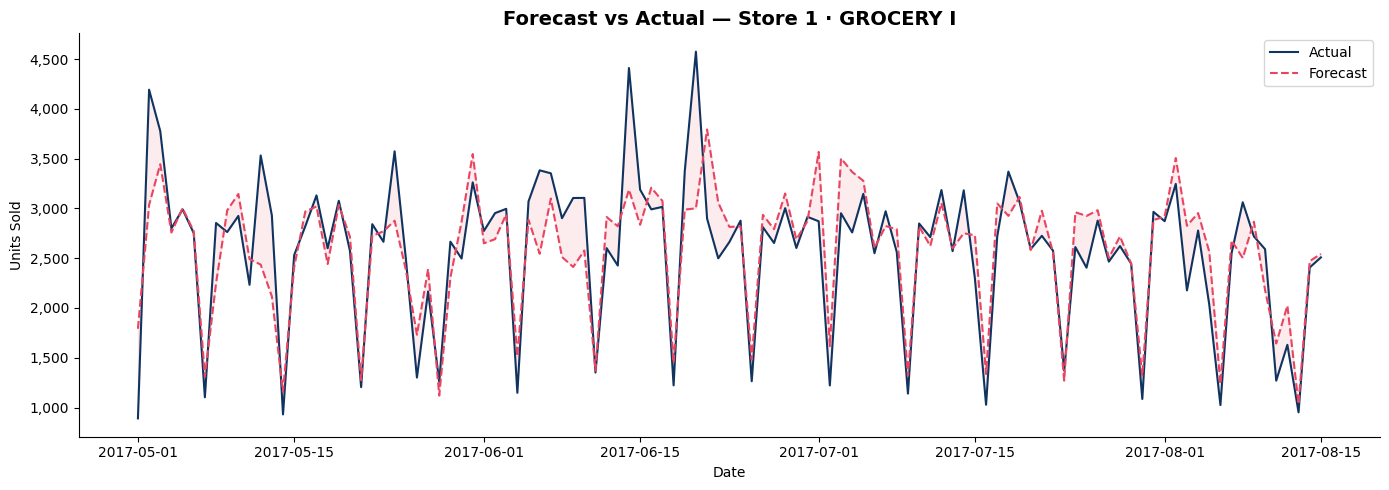

In [23]:
val_df = val_df.copy()
val_df['pred']   = val_preds_raw
val_df['actual'] = val_actual   # already raw units now, no expm1 needed

sample = val_df[(val_df['store_nbr'] == 1) & (val_df['family'] == 'GROCERY I')].sort_values('date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['date'], sample['actual'], label='Actual',   color='#0f3460', linewidth=1.5)
ax.plot(sample['date'], sample['pred'],   label='Forecast', color='#e94560', linewidth=1.5, linestyle='--')
ax.fill_between(sample['date'], sample['actual'], sample['pred'], alpha=0.1, color='#e94560')
ax.set_title('Forecast vs Actual — Store 1 · GROCERY I', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_PATH + 'forecast_vs_actual.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Optuna Optimisation History Plot

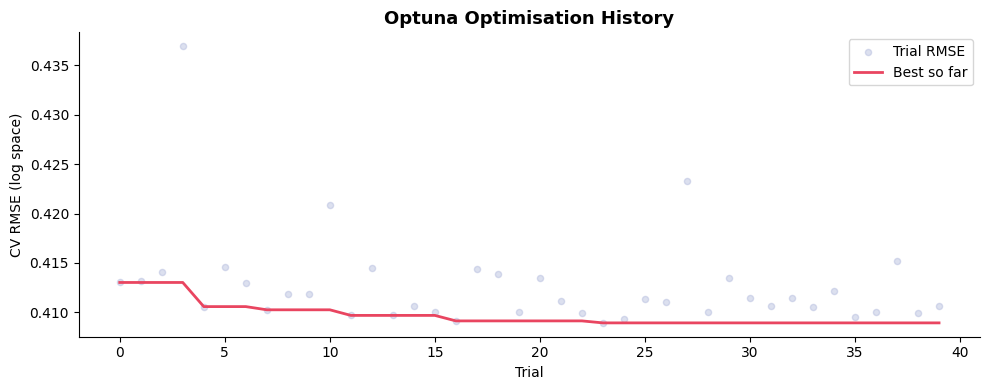

In [24]:
trial_values = [t.value for t in study.trials]
best_so_far  = pd.Series(trial_values).cummin()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(trial_values)), trial_values, alpha=0.4, color='#a8b2d8', s=20, label='Trial RMSE')
ax.plot(range(len(best_so_far)), best_so_far, color='#e94560', linewidth=2, label='Best so far')
ax.set_title('Optuna Optimisation History', fontsize=13, fontweight='bold')
ax.set_xlabel('Trial')
ax.set_ylabel('CV RMSE (log space)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(DATA_PATH + 'optuna_history.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Save Model & Predictions

In [25]:
joblib.dump(final_model, MODEL_PATH + 'lgbm_model.pkl')

val_df[['date','store_nbr','family','actual','pred']].to_parquet(
    DATA_PATH + 'val_predictions.parquet', index=False
)

pd.Series(FEATURE_COLS).to_csv(DATA_PATH + 'feature_cols.csv', index=False)

print('Model saved       :', MODEL_PATH + 'lgbm_model.pkl')
print('Predictions saved :', DATA_PATH + 'val_predictions.parquet')
print()
print('=== Final Results Summary ===')
print(f'RMSE improvement over baseline : {(baseline_rmse-rmse)/baseline_rmse*100:.1f}%')
print(f'WAPE                           : {wape:.2f}%')
print(f'Best Optuna iteration          : {final_model.best_iteration_}')

Model saved       : /content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/models/lgbm_model.pkl
Predictions saved : /content/drive/MyDrive/Colab Notebooks/Demand Forecasting Project/val_predictions.parquet

=== Final Results Summary ===
RMSE improvement over baseline : 36.5%
WAPE                           : 12.10%
Best Optuna iteration          : 769
